In [1]:
from torch.nn import DataParallel
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
# from tqdm import tqdm
from tqdm.notebook import tqdm

import chromadb
from chromadb.config import Settings
import re
from transformers import AutoTokenizer
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.docstore.document import Document
from langchain_community.embeddings import HuggingFaceBgeEmbeddings
import pandas as pd
import os
import pickle
import json
import numpy as np
from typing import List, Dict, Any

import os
from dotenv import load_dotenv, find_dotenv
# env_path = find_dotenv()
# if not env_path:
#     env_path = "/home/yl3427/.env" 
# if not load_dotenv(env_path):
#     raise Exception("Failed to load .env file")

# os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
# # device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
# os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"

In [2]:
print("Number of GPUs detected: ", torch.cuda.device_count())

Number of GPUs detected:  2


In [3]:
json_path = "/secure/shared_data/SOAP/MIMIC/cases_base.json"
# This file looks like
# {
#    hadm_id: {
#           "before_diagnosis": first_half_note, 
#           "after_diagnosis": second_half_note
#    },
#   ...
# }  
with open(json_path, "r") as f:
    cases = json.load(f)
# cases

In [4]:
dir_path = "/secure/shared_data/rag_embedding_model"

tokenizer = AutoTokenizer.from_pretrained("nvidia/NV-Embed-v2", trust_remote_code=True, cache_dir=dir_path)
embedding_model = AutoModel.from_pretrained("nvidia/NV-Embed-v2", trust_remote_code=True, cache_dir=dir_path, device_map="auto")

# embedding_model.to(device)
# embedding_model.half()

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [51]:
type(embedding_model)

transformers_modules.nvidia.NV-Embed-v2.c50d55f43bde7e6a18e0eaa15a62fd63a930f1a1.modeling_nvembed.NVEmbedModel

In [ ]:
# embedding_model.to("cuda")
# for module_key, module in embedding_model._modules.items():
#     print(f"Module: {module_key}, Type: {type(module)}")
#     embedding_model._modules[module_key] = DataParallel(module)

Module: latent_attention_model, Type: <class 'transformers_modules.nvidia.NV-Embed-v2.c50d55f43bde7e6a18e0eaa15a62fd63a930f1a1.modeling_nvembed.LatentAttentionModel'>
Module: embedding_model, Type: <class 'transformers_modules.nvidia.NV-Embed-v2.c50d55f43bde7e6a18e0eaa15a62fd63a930f1a1.modeling_nvembed.BidirectionalMistralModel'>


In [ ]:
# embedding_model._modules['latent_attention_model'].module.device

AttributeError: 'LatentAttentionModel' object has no attribute 'module'

In [ ]:
# embedding_model._modules['embedding_model'].module.device

device(type='cuda', index=0)

Maximum sequence length in chunks: 21041


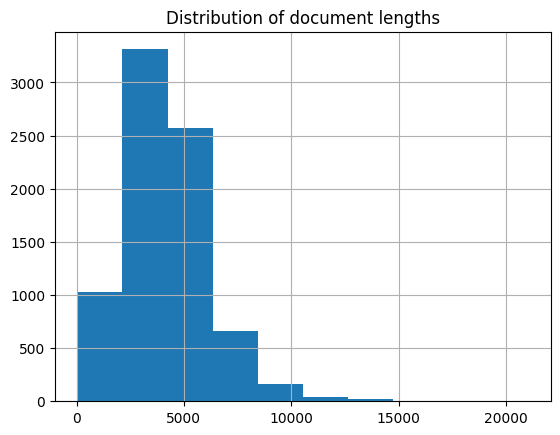

21041


In [5]:
lengths = [len(tokenizer.encode(v["before_diagnosis"])) for k, v in cases.items()]
print(f"Maximum sequence length in chunks: {max(lengths)}")
fig = pd.Series(lengths).hist()
plt.title("Distribution of document lengths")
plt.show()
print(max(lengths))

In [7]:
import re

# Define the regex pattern
pattern = r'(?<=[.?"\s])\s+'

# List of example strings to test
test_strings = [
    "hello? How are you",      # Only the space after '?' is matched
    "Hello.  World",           # The two spaces after '.' are matched
    "Is it true?    Yes",       # The four spaces after '?' are matched
    'She said, "   Hello',      # The three spaces after '"' are matched
    "A  B"                     # No match, because the spaces are not preceded by a character from the set
]

# Check and print which parts of each string match the pattern
for text in test_strings:
    print(f'In: {text!r}')
    for match in re.finditer(pattern, text):
        print(f"  Matched: {match.group()!r} at positions {match.start()}-{match.end()}")
    print()

In: 'hello? How are you'
  Matched: ' ' at positions 6-7

In: 'Hello.  World'
  Matched: '  ' at positions 6-8

In: 'Is it true?    Yes'
  Matched: '    ' at positions 11-15

In: 'She said, "   Hello'
  Matched: '   ' at positions 11-14

In: 'A  B'
  Matched: ' ' at positions 2-3



In [6]:
text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
    separators = ["\n\n", "\n", '(?<=[.?"\s])\s+', " ",  ".", ","],
    tokenizer=tokenizer,
    chunk_size=512,
    chunk_overlap=20,
    add_start_index=True,
    strip_whitespace=True,
    is_separator_regex=True
)
texts = [v["before_diagnosis"] for k, v in cases.items()]
metadatas = [dict(hadm_id=k, full_text=v["before_diagnosis"], diagnosis=v["after_diagnosis"]) for k, v in cases.items()]

In [39]:
docs = (text_splitter.create_documents(texts=[v["before_diagnosis"]], metadatas = [dict(hadm_id=k, full_text=v["before_diagnosis"], diagnosis=v["after_diagnosis"])]) for k, v in cases.items())
# took 3.5mins

In [40]:
docs_processed = []
unique_texts = set()

for doc in docs:
    for chunk in doc:
        if chunk.page_content not in unique_texts:
            unique_texts.add(chunk.page_content)
            docs_processed.append(chunk)


In [12]:
len(texts), len(metadatas)

(7807, 7807)

Maximum sequence length in chunks: 509


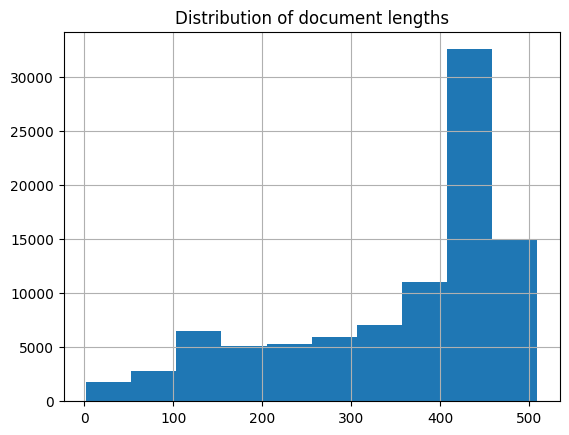

509


In [8]:
lengths = [len(tokenizer.encode(doc.page_content)) for doc in docs_processed]
print(f"Maximum sequence length in chunks: {max(lengths)}")
fig = pd.Series(lengths).hist()
plt.title("Distribution of document lengths")
plt.show()
print(max(lengths))

In [ ]:
MAX_LENGTH = 512
def embed_docs_in_chroma(docs, collection, max_length=MAX_LENGTH):
    pbar = tqdm(total=len(docs))
    for doc in docs:
        id = str(doc.metadata["start_index"])
        doc_text = doc.page_content

        with torch.no_grad():
            embeddings = embedding_model.encode([doc_text], instruction="", max_length=max_length)
            embeddings = embeddings.detach().cpu().numpy().tolist()

        collection.add(
            embeddings=embeddings,
            documents=[doc_text],
            metadatas=[doc.metadata],
            ids=[id],
        )
        pbar.update(1)
        torch.cuda.empty_cache()
        
    pbar.close()

In [2]:
client = chromadb.PersistentClient(path="/secure/shared_data/rag_embedding_model/chroma_db",
                                   settings=Settings(allow_reset=True))

In [3]:
client.list_collections()

[Collection(name=mimic_notes_full)]

In [6]:
# client.get_collection("mimic_notes_full").count()
client.delete_collection("mimic_notes_full")

In [ ]:
mimic_db.d

{'ids': ['167118_0',
  '167118_1215',
  '167118_2262',
  '167118_3195',
  '167118_4574',
  '167118_5615',
  '167118_6629',
  '167118_7518',
  '167118_8513',
  '167118_9102'],
 'embeddings': array([[-0.00947187, -0.02520562, -0.00265831, ...,  0.00870051,
          0.03106546,  0.02193189],
        [-0.0126377 , -0.03049182, -0.02209515, ..., -0.00803192,
          0.01916442,  0.00230495],
        [ 0.01022413, -0.03309699,  0.00330553, ...,  0.00251057,
          0.00980826,  0.0044057 ],
        ...,
        [-0.01587248,  0.00379234, -0.00346825, ..., -0.00203421,
         -0.01160011,  0.00875462],
        [ 0.01635046,  0.00876611,  0.00745625, ...,  0.00647384,
         -0.01118819,  0.01202022],
        [-0.007121  , -0.00864312,  0.01433325, ...,  0.00575557,
          0.00835559,  0.01642017]]),
 'documents': ['admission date:  [**2119-5-4**]              discharge date:   [**2119-5-25**]\n\n\nservice: cardiothoracic\n\nallergies:\namlodipine\n\nattending:[**last name (namepat

In [19]:
client.delete_collection(name="mimic_3prob")
client.delete_collection(name="mimic_test")
client.list_collections()

[Collection(name=lung), Collection(name=brca), Collection(name=lung_test)]

In [25]:
embed_docs_in_chroma(docs_processed, mimic_collection)

  0%|          | 0/93025 [00:00<?, ?it/s]

  0%|          | 18/93025 [31:11<2686:24:10, 103.98s/it]


KeyboardInterrupt: 

In [ ]:
class VectorDB:
    def __init__(self, name: str, api_key = None):
        if api_key is None:
            api_key = os.getenv("VOYAGE_API_KEY")
        self.client = chromadb.PersistentClient("/secure/shared_data/tcga_path_reports/chroma_data/")
        self.name = name
        self.embeddings = []
        self.metadata = []
        self.query_cache = {}
        self.db_path = f"./data/{name}/vector_db.pkl"

    def load_data(self, dataset: List[Dict[str, Any]]):
        if self.embeddings and self.metadata:
            print("Vector database is already loaded. Skipping data loading.")
            return
        if os.path.exists(self.db_path):
            print("Loading vector database from disk.")
            self.load_db()
            return

        texts_to_embed = []
        metadata = []
        total_chunks = sum(len(doc['chunks']) for doc in dataset)
        
        with tqdm(total=total_chunks, desc="Processing chunks") as pbar:
            for doc in dataset:
                for chunk in doc['chunks']:
                    texts_to_embed.append(chunk['content'])
                    metadata.append({
                        'doc_id': doc['doc_id'],
                        'original_uuid': doc['original_uuid'],
                        'chunk_id': chunk['chunk_id'],
                        'original_index': chunk['original_index'],
                        'content': chunk['content']
                    })
                    pbar.update(1)

        self._embed_and_store(texts_to_embed, metadata)
        self.save_db()
        
        print(f"Vector database loaded and saved. Total chunks processed: {len(texts_to_embed)}")

    def _embed_and_store(self, texts: List[str], data: List[Dict[str, Any]]):
        batch_size = 128
        with tqdm(total=len(texts), desc="Embedding chunks") as pbar:
            result = []
            for i in range(0, len(texts), batch_size):
                batch = texts[i : i + batch_size]
                batch_result = self.client.embed(batch, model="voyage-2").embeddings
                result.extend(batch_result)
                pbar.update(len(batch))
        
        self.embeddings = result
        self.metadata = data

    def search(self, query: str, k: int = 20) -> List[Dict[str, Any]]:
        if query in self.query_cache:
            query_embedding = self.query_cache[query]
        else:
            query_embedding = self.client.embed([query], model="voyage-2").embeddings[0]
            self.query_cache[query] = query_embedding

        if not self.embeddings:
            raise ValueError("No data loaded in the vector database.")

        similarities = np.dot(self.embeddings, query_embedding)
        top_indices = np.argsort(similarities)[::-1][:k]
        
        top_results = []
        for idx in top_indices:
            result = {
                "metadata": self.metadata[idx],
                "similarity": float(similarities[idx]),
            }
            top_results.append(result)
        
        return top_results

    def save_db(self):
        data = {
            "embeddings": self.embeddings,
            "metadata": self.metadata,
            "query_cache": json.dumps(self.query_cache),
        }
        os.makedirs(os.path.dirname(self.db_path), exist_ok=True)
        with open(self.db_path, "wb") as file:
            pickle.dump(data, file)

    def load_db(self):
        if not os.path.exists(self.db_path):
            raise ValueError("Vector database file not found. Use load_data to create a new database.")
        with open(self.db_path, "rb") as file:
            data = pickle.load(file)
        self.embeddings = data["embeddings"]
        self.metadata = data["metadata"]
        self.query_cache = json.loads(data["query_cache"])

    def validate_embedded_chunks(self):
        unique_contents = set()
        for meta in self.metadata:
            unique_contents.add(meta['content'])
    
        print(f"Validation results:")
        print(f"Total embedded chunks: {len(self.metadata)}")
        print(f"Unique embedded contents: {len(unique_contents)}")
    
        if len(self.metadata) != len(unique_contents):
            print("Warning: There may be duplicate chunks in the embedded data.")
        else:
            print("All embedded chunks are unique.")

In [42]:
from langchain_community.retrievers import BM25Retriever

In [45]:
bm25_retriever = BM25Retriever.from_documents(docs_processed, k=3)

In [ ]:
query = "pleuritic right chest pain\n- patient started on coumadin\n- [** 949**] briefly decreased (although unclear whether this was due to\naccidental foley removal), [** 949**] responded appropriately to 500 ml lr\nbolus with [** 949**] 60-70 cc\ns per hour this am\n- patient briefly developed non-gap acidosis with bicarb of 19,\nresolved with substitution of lr for ns for fluid boluses\ns: the patient is feeling well.  her chest pain has entirely resolved.\nshe continues to have dry-mouth as well as her baseline amount of cough\nand shortness or breath.  she has not had n/v diarrhea.  no pain or\nswelling in her legs.\nlosartan\nangioedema/lip\nlisinopril (oral)\ncough;\npenicillins\nitching;\nflagyl (oral) (metronidazole)\nwheezing;\nultram (oral) (tramadol hcl)\nrash;\nreview of systems is unchanged from admission except as noted below\nreview of systems:\nlast dose of antibiotics:\nciprofloxacin - [**2141-7-18**] 08:00 pm\nvancomycin - [**2141-7-19**] 08:02 am\ninfusions:\nheparin sodium - 850 units/hour\nother icu medications:\nother medications:\nflowsheet data as of  [**2141-7-20**] 07:16 am\nvital signs\nhemodynamic monitoring\nfluid balance\n24 hours\nsince 12 am\ntmax: 36.9\nc (98.4\ntcurrent: 36.4\nc (97.6\nhr: 80 (73 - 94) bpm\nbp: 99/55(67) {82/37(35) - 125/73(89)} mmhg\nrr: 18 (18 - 28) insp/min\nspo2: 98%\nheart rhythm: sr (sinus rhythm)\nheight: 63 inch\ntotal in:\n2,315 ml\n690 ml\npo:\n270 ml\n60 ml\ntf:\nivf:\n2,045 ml\n630 ml\nblood products:\ntotal out:\n700 ml\n250 ml\nurine:\n700 ml\n250 ml\nng:\nstool:\ndrains:\nbalance:\n1,615 ml\n440 ml\nrespiratory support\no2 delivery device: nasal cannula\nspo2: 98%\nabg: ///22/\ngen: elderly woman in nad, sleeping comfortable\nheent: dry mmm, no jvd\ncv: rrr, no murmurs\nlungs: decreased breath sounds throughout, lungs otherwise clear\nabd: soft, non-tender, +bowel sounds\next: warm and well-perfused, no edema or tenderness\nneuro: responds appropriately to questions, grossly non-focal\n293 k/ul\n8.1 g/dl\n101 mg/dl\n0.6 mg/dl\n22 meq/l\n3.2 meq/l\n9 mg/dl\n111 meq/l\n143 meq/l\n25.0 %\n8.3 k/ul\n[image002.jpg]\n[**2141-7-18**]  08:16 pm\n[**2141-7-19**]  04:10 am\n[**2141-7-20**]  02:55 am\nwbc\n10.6\n8.3\nhct\n24.7\n25.0\nplt\n269\n293\ncr\n0.8\n0.6\ntropt\n0.01\n<0.01\nglucose\n99\n101\nother labs: pt / ptt / inr:15.3/56.2/1.3, ck / ckmb /\ntroponin-t:31/3/<0.01, differential-neuts:77.2 %, lymph:17.6 %,\nmono:4.6 %, eos:0.5 %, lactic acid:1.1 mmol/l, ca++:7.3 mg/dl, mg++:2.0\nmg/dl, po4:1.7 mg/dl"

results = bm25_retriever.get_relevant_documents(query,)

/tmp/ipykernel_2904546/4265483540.py:3: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  results = bm25_retriever.get_relevant_documents(query)


In [105]:
results

[Document(metadata={'hadm_id': '182796', 'full_text': 'admission date:  [**2195-5-30**]              discharge date:   [**2195-6-5**]\n\ndate of birth:  [**2125-8-26**]             sex:   f\n\nservice: medicine\n\nallergies:\npatient recorded as having no known allergies to drugs\n\nattending:[**first name3 (lf) 545**]\nchief complaint:\ns/p fall\n\nmajor surgical or invasive procedure:\nnone\n\nhistory of present illness:\n69 f dm2, cad s/p mult stents, ischemic cm ef 25%, asthma,\nrecent admission to [**hospital unit name **] in [**5-28**] was brought in by family after\na fall.  per husband.  she fell face down on ground around 3 am\nand took her 2 hours to get up in bed stayed at home until this\nam.  this am granddaughter checked bs and was 79 at 10 am and\nwas given her usual dose of 75/25 insulin.\n\non presentation to [**hospital1 18**] er, t 96.5 bp 114/44 hr 88 o2 95%4l,\ninital bg was 8, 16, 65 and after eating 68.  given medications\n[**2-22**] amps of glucose, asa 325, pan

In [ ]:
dir_path = "/secure/shared_data/rag_embedding_model"
tokenizer = AutoTokenizer.from_pretrained("colbert-ir/colbertv2.0")
model = AutoModel.from_pretrained("colbert-ir/colbertv2.0")

ImportError: cannot import name 'HF_ColBERT' from 'transformers' (/home/yl3427/miniconda3/lib/python3.10/site-packages/transformers/__init__.py)

In [4]:
type(model)

transformers.models.bert.modeling_bert.BertModel

In [ ]:
scores = []

def maxsim(query_embedding, document_embedding):

    sim_matrix = torch.nn.functional.cosine_similarity(query_embedding, document_embedding, dim=-1)

    # Take the maximum similarity for each query token (across all document tokens)
    # sim_matrix shape: [batch_size, query_length, doc_length]
    max_sim_scores, _ = torch.max(sim_matrix, dim=2)

    # Average these maximum scores across all query tokens
    avg_max_sim = torch.mean(max_sim_scores, dim=1)
    return avg_max_sim

# Encode the query
query_encoding = tokenizer(query, return_tensors='pt')
query_embedding = model(**query_encoding).last_hidden_state.mean(dim=1)

# Get score for each document
for document in similar_chunks:
    document_encoding = tokenizer(document.page_content, return_tensors='pt', truncation=True, max_length=512)
    document_embedding = model(**document_encoding).last_hidden_state

    # Calculate MaxSim score
    score = maxsim(query_embedding.unsqueeze(0), document_embedding)
    scores.append({
        "score": score.item(),
        "document": document.page_content,
    })

print(f"Took {time.time() - start} seconds to re-rank documents with ColBERT.")

# Cleaned up

In [1]:
import os
import json
import pickle
import torch
import torch.nn.functional as F

from torch.nn import DataParallel
from typing import List, Dict, Any

from transformers import AutoTokenizer, AutoModel
from langchain_community.retrievers import BM25Retriever
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.docstore.document import Document
from langchain_community.embeddings import HuggingFaceBgeEmbeddings

import chromadb
from chromadb.config import Settings
from tqdm import tqdm
from dotenv import load_dotenv, find_dotenv


In [2]:
def create_documents(cases: Dict[str, Any],
                     tokenizer,
                     max_length: int = 512) -> List[Document]:
    """
    Splits clinical text into smaller chunks using a tokenizer-based splitter.
    """
    text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
        separators=[
            "\n\n", "\n", r'(?<=[.?"\s])\s+', " ", ".", ","
        ],
        tokenizer=tokenizer,
        chunk_size=max_length,
        chunk_overlap=20,
        add_start_index=True,
        strip_whitespace=True,
        is_separator_regex=True
    )

    all_docs = []
    unique_texts = set()

    for hadm_id, data in cases.items():
        full_text = data["before_diagnosis"]
        docs = text_splitter.create_documents(
            texts=[full_text],
            metadatas=[{
                "hadm_id": hadm_id,
                "full_text": full_text,
                "diagnosis": data["after_diagnosis"]
            }]
        )
        for d in docs:
            if d.page_content not in unique_texts:
                unique_texts.add(d.page_content)
                all_docs.append(d)

    return all_docs


def embed_docs_in_chroma(docs: List[Document],
                         embedding_model,
                         collection,
                         max_length: int = 512):
    """
    Embeds documents and stores them in a Chroma collection.
    """
    pbar = tqdm(total=len(docs), desc="Embedding Documents")
    for doc in docs:
        doc_text = doc.page_content
        doc_meta = doc.metadata
        doc_id = f"{doc_meta['hadm_id']}_{doc_meta['start_index']}"

        with torch.no_grad():
            embeddings = embedding_model.encode(
                [doc_text],
                instruction="",
                max_length=max_length
            )
            embeddings = embeddings.cpu().numpy().tolist()

        collection.add(
            embeddings=embeddings,
            documents=[doc_text],
            metadatas=[doc_meta],
            ids=[doc_id],
        )
        pbar.update(1)
        torch.cuda.empty_cache()
    pbar.close()


In [15]:
def hybrid_query(cases: Dict[str, Any],
                 docs: List[Document],
                 collection,
                 embedding_model,
                 query_text: str,
                 query_prefix: str,
                 max_length: int = 512,
                 semntic_k: int = 5,
                 bm25_k: int = 5,
                 bm25_weight: float = 0.5) -> List[str]:
    """
    Performs a hybrid query using semantic (Chroma) + BM25.
    """
    # --- Semantic Retrieval ---
    query_embedding = embedding_model.encode(
        [query_text],
        instruction=query_prefix,
        max_length=max_length
    ).cpu().numpy().tolist()

    results_semantic = collection.query(
        query_embeddings=query_embedding,
        n_results=semntic_k,
    )
    results_semantic_ids = [full_id.split("_")[0] for full_id in results_semantic["ids"][0]]

    # --- BM25 Retrieval ---
    bm25_retriever = BM25Retriever.from_documents(docs, k=bm25_k)
    results_bm25 = bm25_retriever.get_relevant_documents(query_text)
    results_bm25_ids = [doc.metadata["hadm_id"] for doc in results_bm25]

    # Intersection
    combined_ids = set(results_semantic_ids) & set(results_bm25_ids)

    # Weighted scoring
    semantic_weight = 1.0 - bm25_weight
    ids_to_score = {}

    for chunk_id in combined_ids:
        score = 0.0
        if chunk_id in results_semantic_ids:
            idx_sem = results_semantic_ids.index(chunk_id)
            score += semantic_weight * (1 / (idx_sem + 1))
        if chunk_id in results_bm25_ids:
            idx_bm25 = results_bm25_ids.index(chunk_id)
            score += bm25_weight * (1 / (idx_bm25 + 1))
        ids_to_score[chunk_id] = score

    sorted_ids = sorted(ids_to_score.keys(), key=lambda x: ids_to_score[x], reverse=True)

    retrieved_docs = []
    for doc_id in sorted_ids:
        before = cases[doc_id]["before_diagnosis"]
        after = cases[doc_id]["after_diagnosis"]
        retrieved_docs.append(f"{before}\nDischarge Diagnosis: {after}")

    return retrieved_docs

In [5]:
env_path = find_dotenv()
if not env_path:
    env_path = "/home/yl3427/.env"

if not load_dotenv(env_path):
    raise Exception("Failed to load .env file")
    
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
os.environ["CUDA_VISIBLE_DEVICES"] = "0, 1"


with open("/secure/shared_data/SOAP/MIMIC/cases_base.json", "r") as f:
    cases = json.load(f)

print(f"Loaded {len(cases)} cases.")

Loaded 7807 cases.


In [6]:
dir_path = "/secure/shared_data/rag_embedding_model"
tokenizer = AutoTokenizer.from_pretrained(
    "nvidia/NV-Embed-v2",
    trust_remote_code=True,
    cache_dir=dir_path
)

docs_processed = create_documents(cases, tokenizer, max_length=512)
print(f"Total doc chunks: {len(docs_processed)}")

Total doc chunks: 93025


In [9]:
docs_processed = docs_processed[:10]

In [10]:
# 4) Connect to Chroma
client = chromadb.PersistentClient(
    path="/secure/shared_data/rag_embedding_model/chroma_db",
    settings=Settings(allow_reset=True)
)
mimic_collection = client.get_or_create_collection(
    name="mimic_test",
    metadata={"hnsw:space": "cosine"}
)
print("Current collection count:", mimic_collection.count())

Current collection count: 0


In [ ]:
# 5) Load/Initialize Embedding Model & Embed Docs
embedding_model = AutoModel.from_pretrained(
    "nvidia/NV-Embed-v2",
    trust_remote_code=True,
    cache_dir=dir_path,
    device_map="auto"
)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [12]:
# If needed to embed new docs:
embed_docs_in_chroma(docs_processed, embedding_model, mimic_collection, max_length=512)
print("New collection count:", mimic_collection.count())

Embedding Documents:   0%|          | 0/10 [00:00<?, ?it/s]/home/yl3427/.cache/huggingface/modules/transformers_modules/nvidia/NV-Embed-v2/c50d55f43bde7e6a18e0eaa15a62fd63a930f1a1/modeling_nvembed.py:349: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'input_ids': torch.tensor(batch_dict.get('input_ids').to(batch_dict.get('input_ids')).long()),
Embedding Documents:  10%|█         | 1/10 [00:04<00:44,  4.99s/it]/home/yl3427/.cache/huggingface/modules/transformers_modules/nvidia/NV-Embed-v2/c50d55f43bde7e6a18e0eaa15a62fd63a930f1a1/modeling_nvembed.py:349: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'input_ids': torch.tensor(batch_dict.get('input_ids').to(batch_dict.get('input_ids')).long(

New collection count: 10


In [16]:
query_prefix = (
    "Given the following clinical note, retrieve the most relevant passages from similar clinical cases.\n"
    "Clinical note:\n\n"
    )
query_text = (
    "pleuritic right chest pain\n- patient started on coumadin\n..."
    "respiratory support\no2 delivery device: nasal cannula\nspo2: 98%\n..."
    # (Truncated for brevity)
)

retrieved = hybrid_query(
    cases=cases,
    docs=docs_processed,
    collection=mimic_collection,
    embedding_model=embedding_model,
    query_text=query_text,
    query_prefix=query_prefix,
    max_length=512,
    semntic_k=5,
    bm25_k=5,
    bm25_weight=0.5
)

for idx, doc in enumerate(retrieved, start=1):
    print(f"\n--- Retrieved Doc #{idx} ---")
    print(doc)



--- Retrieved Doc #1 ---
admission date:  [**2192-4-19**]              discharge date:   [**2192-5-23**]


service: medicine

allergies:
lisinopril

attending:[**first name3 (lf) 1865**]
chief complaint:
diarrhea

major surgical or invasive procedure:
none

history of present illness:
mrs. [**known lastname **] is an 84 yo f h/o cri, htn, gerd, colon ca,
neprhotic syndrome, dc'd [**3-31**] after low anterior resection of
colon. now p/w 1wk h/o diarrhea worsened one day prior to
admission, found to have wbcc 30 in ed, admitted [**4-19**] and
started on both p.o. vanco and iv flagyl. began to have brbpr on
[**4-25**], on [**4-30**] had flex sigmoidoscopy showing pseudomembranes with
recurrent c.diff vs. bowel ischemia as etiology. then developed
some sob/fluid overload and was started on lasix and neseritide
gtt's. had had some intermittent afib which was thought to be
contributing to presumed diastolic dysfunction. tx to ccu
[**2192-5-12**] for worsening tachypnea and oliguria on nesir

/tmp/ipykernel_3178592/310063232.py:29: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  results_bm25 = bm25_retriever.get_relevant_documents(query_text)


In [17]:
len(retrieved)

1